# EJERCICIO 1

PUNTO 1

In [1]:
# Librerias a utilizar

import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

C:\Users\fedew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:

df = pd.read_excel("datasets/flete-aereo-vacunas-covid19-al-2021-06-28.xlsx", header=4)

#df.info()
#print(df.head(10))

df.rename(columns={old_name: new_name for old_name, new_name in 
zip(df.columns, [col.replace(' ', '') for col in df.columns])}, inplace=True)

#print(df.columns)

#Calculo la frecuencia de vuelos
frecuencia_vuelos = df['vuelo'].value_counts()
#print(frecuencia_vuelos)

#Calculo el porcentaje de cada vuelo
porcentaje_vuelos = (frecuencia_vuelos/df['vuelo'].count())
#print(round(porcentaje_vuelos * 100, 2))


PUNTO 2

In [ ]:
#Vemos que tipo de datos tenemos en la columna vuelo
#print(df.vuelo.unique())

#Cuento los registros donde 'vuelo' es NaN (no contiene informacion). 
#(Cantidad Absurda, el df esta lleno de NaN al final, hay que limpiarlos)
registros_sin_vuelos = df['vuelo'].isna().sum()
print("antes de limpiar los NaN:", registros_sin_vuelos)

df.dropna(axis=0, thresh=3, inplace=True)
registros_sin_vuelos = df['vuelo'].isna().sum()
print("\ndespues de limpiar los NaN:", registros_sin_vuelos)

PUNTO 3

In [ ]:
print(df['factura_moneda_monto'].head(15))

#Hacer con REGEX. Repasar

PUNTO 4

In [ ]:
# Calculo la cantidad de vuelos que hay con origen en rusia y con origen en china. 
vuelos_china_rusia = len(df[(df['origen'] == 'Rusia')|(df['origen'] == 'China')])

# Calculo y muesto el porcentaje sobre el total de vuelos
print(f"El porcentaje de vuelos con origen desde Rusia y China es: {round(vuelos_china_rusia / len(df) * 100, 2)}%")

PUNTO 5

In [ ]:
# Utilizo las funciones maximo/minimo para mostrar cual fue el vuelo mas reciente/antiguo. 
print("Vuelo mas reciente: ", df['fecha_guía'].max())
print("Vuelo mas antiguo: ", df['fecha_guía'].min())

# Cantidad de dias entre vuelos, calculado solamente haciendo la diferencia entre lo que nos devuelven
# las funciones max/min
print("Cantidad de dias entre vuelos: ", max(df['fecha_guía']) - min(df['fecha_guía']))


PUNTO 6

In [ ]:
# Antes convertimos la columna 'vuelo' a tipo str
df['vuelo'] = df['vuelo'].astype(str)

# Escribimos el DataFrame en formato Parquet
df.to_parquet('vuelos_covid.parquet')               #me tira error


# Utilizando PyArrow

# Convertimos el DataFrame en una tabla de pyArrow
tabla = pa.Table.from_pandas(df)

# Escribimos el archivo Parquet
pq.write_table(tabla, 'datos.parquet')

# EJERCICIO 2

In [35]:
df_incendios = pd.read_csv("./datasets/incendios-cantidad-causas-provincia_2022.csv", encoding='latin-1', header=3)

#VISUALIZACION Y ADECUACION
df_incendios.head(15)
#df_incendios.info()
#df_incendios.isnull().sum()

df_incendios['natural'] = df_incendios['natural'].str.replace('-', '0')
df_incendios = df_incendios.rename(columns= {'anio' : 'año'})
df_incendios['provincia'] = df_incendios['provincia'].str.strip() #para corregir espacios al final y al principio
df_incendios['provincia'] = df_incendios['provincia'].replace({'Cordoba' : 'Córdoba'}) # para corregir dos provincias con mismo nombre

df_incendios['provincia'].sort_values().unique()
df_incendios.head(22)


,año,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0
3,1993,Chubut,21,18,0,0,3
4,1993,Córdoba,151,0,0,0,151
5,1993,Corrientes,48,0,0,0,48
6,1993,Entre Ríos,179,0,0,0,179
7,1993,Formosa,1,0,1,0,0
8,1993,Jujuy,0,0,0,0,0
9,1993,La Pampa,67,0,0,0,67


PUNTO 1

In [55]:
# OBTENGO LA CANTIDAD DE INCENCIOS POR AÑO PARA TODO EL PAIS 
# Y LUEGO OBTENGO EL AÑO CON MAYOR CANT DE INCENDIOS

cant_incendios_años = df_incendios.groupby('año')['total'].sum()

mayor_cantidad = cant_incendios_años.idxmax()

print(mayor_cantidad)

2008


PUNTO 2

In [60]:
# Primero filtro por la provincia de Cordoba y tambien 
# filtro por separado por el rango de años solicitados
filtro_años_cordoba = df_incendios[(df_incendios['año'].between(1993, 2021)) & (df_incendios['provincia'] == 'Córdoba')]

# Calculo la cantidad de incendios por año
incendios_cordoba_años = filtro_años_cordoba.groupby('año')['total'].sum()

print(incendios_cordoba_años)

año
1993     151
1994     161
1995    2441
1996      92
1997     387
1998     307
1999      55
2000     869
2001     194
2002     101
2003     119
2004     154
2006     438
2007     346
2008     157
2009     229
2011     147
2012     135
2013     173
2014     291
2019     273
2020     264
2021     198
Name: total, dtype: int64


PUNTO 3

In [ ]:
# Primero filtro el rando de años solicitados
filtro_años = df_incendios[df_incendios['año'].between(1993, 2021)]

# Segundo, agrupo por años los datos, luego solo trabajo con la columna 'intencional' y 
# extraigo cada indice del maximo de incencios en cada grupo de años.
indices_maximos = filtro_años.groupby('año')['intencional'].idxmax()

# Creo la tabla con .loc, al cual le paso los indices_maximos para que filtre el 
# df original, y las columnas de mi interes. Agrego tambien .reset_index para que arranque con el 
# indice 0 y no con el del df original
tabla_maximos = filtro_años.loc[indices_maximos, [ 'año', 'provincia', 'intencional']].reset_index(drop=True)

print(tabla_maximos)

     año         provincia  intencional
0   1993  Tierra del Fuego            2
1   1994         Río Negro            7
2   1995         Río Negro          250
3   1996         Catamarca         1662
4   1997         Río Negro          453
5   1998      Buenos Aires          583
6   1999             Chaco          503
7   2000             Chaco          549
8   2001             Chaco          284
9   2002      Buenos Aires          358
10  2003         Río Negro          790
11  2004          Santa Fe          290
12  2005           Córdoba          515
13  2006          Santa Fe          581
14  2007         Río Negro         1154
15  2008         Río Negro         1528
16  2009         Río Negro         1074
17  2010         Río Negro          988
18  2011          Santa Fe         1214
19  2012          Santa Fe         1472
20  2013          Santa Fe         1158
21  2014          Santa Fe          617
22  2015          Santa Fe          592
23  2016          Santa Fe          702


Punto 4

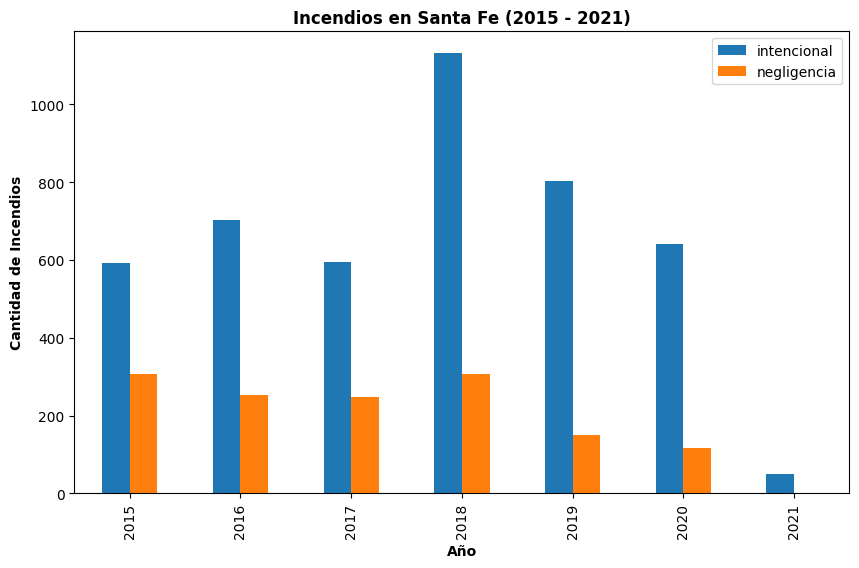

In [ ]:
# Primero filtro el dataset con el rango de años y la provincia de Santa Fe
filtro_años_sta_fe = df_incendios[(df_incendios['año'].between(2015, 2021)) & (df_incendios['provincia'] == 'Santa Fe')]

# Agrupo por años, trabajo solo con las columnas intencional, negligencia y natural, y sumo sus resultados
incendios_santa_fe = filtro_años_sta_fe.groupby('año')[['intencional', 'negligencia', 'natural']].sum()

# Creo el grafico con un tamaño de x=10, y=6
incendios_santa_fe.plot.bar(figsize=(10, 6))

# Le pongo un titulo y nombre a los ejes, con el detalle de que este en negrita.
plt.title("Incendios en Santa Fe (2015 - 2021)", fontweight="bold")
plt.xlabel("Año", fontweight="bold")
plt.ylabel("Cantidad de Incendios", fontweight="bold")
plt.show()

PUNTO 5

In [ ]:
# Primero filtro el dataset con el rango de años y la provincia de Rio Negro
filtro_años_rio_negro = df_incendios[(df_incendios['año'].between(1993, 2021)) & (df_incendios['provincia'] == 'Río Negro')]

# Corrijo columna natural que tenia formato str y no int
filtro_años_rio_negro['natural'] = filtro_años_rio_negro['natural'].astype(int)

# Calculo el promedio para las columnas intencional, natural y negligencia y redondeo los resultados a 2 decimales
promedio_tipo_incendio = round(filtro_años_rio_negro[['intencional', 'natural', 'negligencia']].mean(), 2)

promedio_tipo_incendio

intencional    343.76
natural         18.90
negligencia    240.97
dtype: float64

# EJERCICIO 3

In [ ]:
def interpolacion_tramos(x: int) -> int:
    x_datos = [1, 2, 3, 10]
    y_datos = [2, 3, 5, 6]

    # Manejo los limites de la variable x
    if x <= x_datos[0]:
        return y_datos[0]
    if x >= x_datos[-1]:
        return y_datos[-1]
    
    # Recorro los RANGOS de la tabla
    for i in range(len(x_datos) - 1):

        # Defino el inicio y el final de cada rango, y su imagen
        x0, x1 = x_datos[i], x_datos[i+1]
        y0, y1 = y_datos[i], y_datos[i+1]

        # Corroboro si x esta en el rango
        if x0 <= x <= x1:
            # Aplico la formula de interpolacion
            y = y0 + (x - x0) * ((y1 - y0) / (x1-x0))
            
            return y

# Vamos a probar con un valor exacto de la tabla (debería dar 3)
print("Si x = 2.0, y =", interpolacion_tramos(2.0))

# Vamos a probar con un valor en el tramo entre 2 y 3 (debería dar un valor entre 3 y 5)
print("Si x = 2.5, y =", interpolacion_tramos(2.5))

# Vamos a probar con un valor en el tramo largo entre 3 y 10 
print("Si x = 6.5, y =", interpolacion_tramos(6.5))

Si x = 2.0, y = 3.0
Si x = 2.5, y = 4.0
Si x = 6.5, y = 5.5


# EJERCICIO 4

In [ ]:
# 1. Cargamos los datos de la tabla de la consigna. 
# Usamos np.nan para representar los huecos vacíos.
datos = {
    'Año': [1960, 1970, 1978, 1980, 1986, 1991, 2001, 2010, 2014, 2022],
    'Pob_Total': [20013793, 23364431, np.nan, 27949780, np.nan, 32615528, 36260130, 40117096, np.nan, 46044703]
}

poblacion_historica = pd.DataFrame(datos)

# Establecemos la columna 'Año' como el índice de la tabla.
# Esto le dice a Pandas: "Las distancias matemáticas están en esta columna"
poblacion_historica = poblacion_historica.set_index('Año')

# Ejecutamos la interpolación. 
# Pasamos el parámetro method='index' para que respete los espacios desiguales de los años.
poblacion_historica['Pob_Estimada'] = poblacion_historica['Pob_Total'].interpolate(method='index')

# Ajuste final de calidad de datos.
# La interpolación nos dará números con decimales, pero no existen mitades de personas
# Redondeamos (.round) y convertimos a número entero (.astype(int)).
poblacion_historica['Pob_Estimada'] = poblacion_historica['Pob_Estimada'].round().astype(int)

# Vemos el resultado
poblacion_historica

,Pob_Total,Pob_Estimada
Año,,
1960,20013793.0,20013793
1970,23364431.0,23364431
1978,NaN,27032710
1980,27949780.0,27949780
1986,NaN,30494733
1991,32615528.0,32615528
2001,36260130.0,36260130
2010,40117096.0,40117096
2014,NaN,42092965


# EJERCICIO 5

PUNTO 1


In [35]:
alquileres = pd.read_csv("datasets/listings_ba.csv")

# Limpieza y adecuacion

alquileres.info()
#alquileres.head(15)
#alquileres['room_type'].unique()

nulos_iniciales = alquileres['price'].isnull().sum()
print("Notamos que hay", nulos_iniciales, "nulos en la columna price inicialmente")

alquileres[['neighbourhood', 'room_type', 'latitude', 'longitude']].head() # Columnas a usar

<class 'pandas.DataFrame'>
RangeIndex: 20085 entries, 0 to 20084
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20085 non-null  int64  
 1   name                            20082 non-null  str    
 2   host_id                         20085 non-null  int64  
 3   host_name                       20085 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   20085 non-null  str    
 6   latitude                        20085 non-null  float64
 7   longitude                       20085 non-null  float64
 8   room_type                       20085 non-null  str    
 9   price                           19985 non-null  float64
 10  minimum_nights                  20085 non-null  int64  
 11  number_of_reviews               20085 non-null  int64  
 12  last_review                     16254 non-n

,neighbourhood,room_type,latitude,longitude
0,Palermo,Entire home/apt,-34.58184,-58.42415
1,Palermo,Entire home/apt,-34.58617,-58.41036
2,Palermo,Private room,-34.58992,-58.42236
3,Nuñez,Private room,-34.53892,-58.46599
4,Palermo,Entire home/apt,-34.58311,-58.42767


PUNTO 1

In [36]:
# Calculamos media y moda sobre la columna price
media = alquileres['price'].mean().round()
moda = alquileres['price'].mode()[0]
print(media, moda)

# Reemplazamos con la media, la cual es un valor mas acertado que representa a la mayoria de los datos
alquileres['price_imputado_media'] = alquileres['price'].fillna(media)
alquileres.info()

16479.0 8810.0
<class 'pandas.DataFrame'>
RangeIndex: 20085 entries, 0 to 20084
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20085 non-null  int64  
 1   name                            20082 non-null  str    
 2   host_id                         20085 non-null  int64  
 3   host_name                       20085 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   20085 non-null  str    
 6   latitude                        20085 non-null  float64
 7   longitude                       20085 non-null  float64
 8   room_type                       20085 non-null  str    
 9   price                           19985 non-null  float64
 10  minimum_nights                  20085 non-null  int64  
 11  number_of_reviews               20085 non-null  int64  
 12  last_review                 

PUNTO 2

In [ ]:
# Usamos el metodo transform(mean) en vez del mean() clasico, ya que este 
# en lugar de aplastar la tabla, devuelve un resultado del mismo tamaño que 
# la tabla original, repartiendo el valor calculado a quien le corresponda.
media_barrio_habitacion2 = alquileres.groupby(['neighbourhood', 'room_type'])['price'].transform('mean')

listing['price_imputado_grupos'] = listing['price'].fillna(media_barrio_habitacion2)

# EJERCICIO 6

PUNTO 1

In [3]:
def validar_url(url: str) -> None:
    url_valida = r"https?://[\w.-]+\.[a-zA-Z]{2,}\b"
    if re.match(url_valida, url):
        print("URL válida")
    else:
        print("URL no válida")
    return

strr = "https://pythondiario.com/"
validar_url(strr)

URL válida


PUNTO 2

In [ ]:
def validar_gmail(gmail: str) -> None:
    url_gmail = r"^[\w.]+@gmail\.com$"
    if re.match(url_gmail, gmail):
        print("GMAIL válido")
    else:
        print("GMAIL no válido")
    return

strr = "hola_como22@gmail.com"
validar_gmail(strr)

GMAIL válido


PUNTO 4

In [ ]:
def validar_fecha(fecha):
    # Desarmando el patrón:
    # ^ : Empieza la línea
    # \d{4} : Exactamente 4 dígitos para el año (ej. 2023)
    # - : Un guion literal
    # (0[1-9]|1[0-2]) : El mes. O bien empieza con 0 y sigue con 1-9 (01 a 09), o bien empieza con 1 y sigue con 0-2 (10 a 12).
    # - : Un guion literal
    # (0[1-9]|[12]\d|3[01]) : El día. Del 01 al 09, o del 10 al 29 ([12]\d), o el 30/31.
    # $ : Termina la línea
    
    patron_fecha = r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$"
    
    if re.match(patron_fecha, fecha):
        print(f"'{fecha}' es una fecha VÁLIDA.")
    else:
        print(f"'{fecha}' es una fecha NO VÁLIDA.")

# Probamos la función
validar_fecha("2023-10-25")  # VÁLIDO
validar_fecha("2023-13-05")  # NO VÁLIDO (el mes 13 no existe)
validar_fecha("2023-12-32")  # NO VÁLIDO (el día 32 no existe)

PUNTO 3

In [10]:
def analizar_cancion():
    # 1. Leemos el archivo completo y lo guardamos en un string
    with open("datasets/Me_gustas_tu-Manu_Chao.txt", "r", encoding="utf-8") as file:
        letra = file.read()
    
    # --- Parte 1: Contar el verbo 'gustar' ---
    # Usamos re.findall para buscar todas las apariciones de "gusta" o "gustas"
    # El patrón r"gustas?" busca "gusta" seguido opcionalmente de una "s"
    # Usamos flags=re.IGNORECASE por si dice "Gusta" con mayúscula
    apariciones_gustar = re.findall(r"gustas?", letra, flags=re.IGNORECASE)
    print(f"1. El verbo gustar (gusta/gustas) aparece: {len(apariciones_gustar)} veces.")
    
    # --- Parte 2: Contar verbos en infinitivo ---
    # Los verbos en infinitivo terminan en ar, er, ir.
    # El patrón \b asegura que sea el final de una palabra completa.
    # El patrón \w+ busca letras antes de la terminación.
    verbos_infinitivo = re.findall(r"\b\w+(?:ar|er|ir)\b", letra, flags=re.IGNORECASE)
    # Convertimos a un set() para contar cuántos verbos ÚNICOS hay, sin repetir
    cantidad_unicos = len(set(verbos_infinitivo))
    print(f"2. Se encontraron {cantidad_unicos} verbos únicos en infinitivo.")
    
    # --- Parte 3: Extraer qué le gusta ---
    # El patrón busca la frase "Me gusta(s) " o "Me gustan " y captura lo que sigue
    # (.*) captura todo hasta el final de esa línea
    # re.MULTILINE permite que el ^ funcione en cada línea de la letra
    patron_cosas = r"^[Mm]e gustan?\s+(.*)$"
    cosas = re.findall(patron_cosas, letra, flags=re.MULTILINE)
    
    # Limpiamos un poco la lista (Manu chao a veces repite frases)
    cosas_unicas = list(set(cosas))
    print(f"\n3. Cosas que le gustan a Manu Chao (Lista reducida):")
    print(cosas_unicas[:10]) # Mostramos solo las primeras 10 para no saturar

analizar_cancion()

1. El verbo gustar (gusta/gustas) aparece: 54 veces.
2. Se encontraron 8 verbos únicos en infinitivo.

3. Cosas que le gustan a Manu Chao (Lista reducida):
['la canela, me gustas tú', 'la lluvia, me gustas tú', 'camelar, me gustas tú', 'su cocina, me gustas tú (una de la mañana)', 'Malasaña, me gustas tú', 'correr, me gustas tú', 'La Coruña, me gustas tú', 'los aviones, me gustas tú', 'la vecina, me gustas tú (Radio Reloj)', 'la cena, me gustas tú']


# EJERCICIO 7

In [ ]:
personas = pd.read_excel("datasets/conicet_personas_2020.xlsx")
sexo = pd.read_excel("datasets/conicet_ref_sexo.xlsx")
grado_academico = pd.read_excel("datasets/conicet_ref_grado_academico.xlsx")

,grado_academico_id,descripcion
0,-1,Sin datos
1,1,Universitario de posgrado/doctorado
2,2,Universitario de posgrado/maestria
3,3,Universitario de posgrado/especializacion
4,4,Universitario de posgrado/perfeccionamiento
5,5,Universitario de grado
6,6,Terciario no universitario
7,7,Medio
8,8,Basico
9,9,Universitario de posdoctorado


In [ ]:
# Renombro la columna de maximo grado academico para poder hacer un merge con 
# el df de grados academicos.
personas = personas.rename(columns={'maximo_grado_academico_id':'grado_academico_id'})

In [ ]:
# Primero hacemos un merge de todas las tablas para poder 
# trabajar con mas comodidad
conicet_medio = pd.merge(personas, grado_academico, on='grado_academico_id')
conicet = pd.merge(conicet_medio, sexo, on='sexo_id')

# Opcion 1: metodo unstack() -> metodo estructural (no calcula nada)
resuelto1 = conicet.groupby('sexo_descripcion')['descripcion'].value_counts().unstack()

# Opcion 2: metodo crosstab() -> funcion estadistica
resuelto2 = pd.crosstab(conicet['descripcion'], conicet['sexo_descripcion'])


descripcion,Basico,Medio,Sin datos,Terciario no universitario,Universitario de grado,Universitario de posgrado/doctorado,Universitario de posgrado/especializacion,Universitario de posgrado/maestria
sexo_descripcion,,,,,,,,
FEMENINO,17,622,391,249,14426,15695,6091,6384
MASCULINO,8,454,328,201,10608,12428,3543,4546


# EJERCICIO 8

In [41]:
df_incendios.head()

,año,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0
3,1993,Chubut,21,18,0,0,3
4,1993,Córdoba,151,0,0,0,151


In [ ]:
# Opcion 1
intencionales1 = df_incendios.groupby(['provincia', 'año'])['intencional'].sum().unstack()

# Opcion 2: usando tablas pivotantes. Le podes decir exactamente en cada fila, columna 
# y que queres sumar
intencionales2 = pd.pivot_table(
    df_incendios,
    values='intencional',
    index='provincia',
    columns='año',
    aggfunc='sum'
)

# Ambas opciones generan lo mismo

año,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
provincia,,,,,,,,,,,,,,,,,,,,,
Buenos Aires,0.0,0.0,0.0,0.0,164.0,583.0,447.0,239.0,184.0,358.0,...,7.0,11.0,31.0,83.0,102.0,21.0,39.0,0.0,209.0,0.0
Catamarca,0.0,0.0,0.0,1662.0,9.0,6.0,3.0,9.0,9.0,147.0,...,29.0,7.0,3.0,24.0,23.0,20.0,5.0,1.0,4.0,3.0
Chaco,0.0,0.0,0.0,12.0,7.0,32.0,503.0,549.0,284.0,150.0,...,0.0,3.0,0.0,0.0,0.0,0.0,33.0,NaN,5.0,0.0
Chubut,0.0,0.0,2.0,76.0,29.0,71.0,47.0,32.0,22.0,27.0,...,39.0,34.0,31.0,40.0,23.0,10.0,9.0,12.0,9.0,7.0
Ciudad Autónoma de Buenos Aires,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Corrientes,0.0,0.0,0.0,58.0,39.0,2.0,326.0,0.0,1.0,1.0,...,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
Córdoba,0.0,0.0,0.0,0.0,121.0,107.0,0.0,340.0,17.0,8.0,...,135.0,173.0,291.0,1.0,92.0,76.0,83.0,223.0,241.0,1.0
Entre Ríos,0.0,0.0,0.0,0.0,45.0,57.0,216.0,0.0,37.0,10.0,...,45.0,21.0,12.0,5.0,0.0,0.0,21.0,0.0,0.0,0.0
Formosa,1.0,1.0,1.0,2.0,6.0,4.0,4.0,18.0,5.0,0.0,...,0.0,0.0,50.0,65.0,54.0,58.0,85.0,90.0,0.0,0.0


# EJERCICIO 10

In [3]:
dfventas = pd.read_excel("datasets/ventas.xlsx")
dfclientes = pd.read_excel("datasets/clientes_base.xlsx")

dfventas.head(20)

,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto
0,C1,Juana Perez,Apple Watch Series 8,2,399
1,C2,Roberto Gomezz,Nintendo Switch,1,299
2,C3,Carla Gonzáles Cuispe,Bose QuietComfort 45,1,329
3,C4,Jorge Martinez,Acer Predator Helios 300,1,1599
4,C5,Mariano Rodriguéz,iPad Pro,1,1099
5,C6,Roberto Gómez Acuña,HP Spectre x360,1,1399
6,C7,Maria Garcìa,MacBook Air,1,1249
7,C8,Carlos Gonzales,Samsung Galaxy S22,3,849
8,C9,Miguel Ánjel,Dell Alienware,1,1999
9,C10,María García,Amazon Echo Dot,3,49


In [4]:
#df2.info()
dfclientes.head(15)

,id_cliente,nombre_cliente,ciudad,email
0,1,Lucia Fernandez,Villa María,luciaf2@mail.com
1,2,Carlos Gómez,Mendoza,carlosgomez@mail.com
2,3,Andrés Pérez,Corrientes,andresp3@mail.com
3,4,Roberto Gómez,Rosario,rgomez@mail.com
4,5,Roberto Gómez Acuña,Corrientes,robgoac@mail.com
5,6,Juana Pérez,Salta,juanaperez@mail.com
6,7,Lucía Hernández,Santa Fe,luciahernandez@mail.com
7,8,Andrés Pérez Gollán,Mar del Plata,andresp@mail.com
8,9,Miguel Ángel,Neuquén,miguelangel@mail.com
9,10,Marcos Rupetti,Bariloche,marcosg@mail.com


PUNTO 1

In [5]:
ventas_ipad_mac = dfventas[dfventas['producto'].str.contains('iPad|MacBook')]

#print(ventas_ipad)
ventas_ipad_mac['monto'] = ventas_ipad_mac['precio_usd_producto'] * ventas_ipad_mac['cantidad']

monto_total = ventas_ipad_mac['monto'].sum()

print(monto_total)
ventas_ipad_mac

6663


,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto,monto
4,C5,Mariano Rodriguéz,iPad Pro,1,1099,1099
6,C7,Maria Garcìa,MacBook Air,1,1249,1249
15,C16,Laura Martínez,iPad mini,1,559,559
18,C19,Andres Pérrez,MacBook Pro,1,1999,1999
22,C23,Andres Péres,iPad Air,2,599,1198
38,C39,Juan Perez,iPad mini,1,559,559


PUNTO 2

In [7]:
union = pd.merge(dfventas, dfclientes, on='nombre_cliente')

# Se nota que en el dataframe dfventas hay 42 entradas a diferencia del dataframe resultante 
# que tiene solo 14 entradas.

dfventas.info()
dfclientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id_venta             42 non-null     str  
 1   nombre_cliente       42 non-null     str  
 2   producto             42 non-null     str  
 3   cantidad             42 non-null     int64
 4   precio_usd_producto  42 non-null     int64
dtypes: int64(2), str(3)
memory usage: 3.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_cliente      36 non-null     int64
 1   nombre_cliente  36 non-null     str  
 2   ciudad          36 non-null     str  
 3   email           36 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.7 KB


PUNTO 3

In [8]:
porcentaje = round((union['nombre_cliente'].count() / dfclientes['nombre_cliente'].count()) * 100, 2)

print(porcentaje, "%")

38.89 %


# EJERCICIO 11

PUNTO 1

In [ ]:
# 1 Creamos el diccionario con los datos
datos = {
    # NOTA: Guardamos los 'id' como texto (entre comillas) 
    # para no perder los ceros a la izquierda.
    'id': ['0049570', '0769298', '8458909'],
    'desc_prod': ['camisa', 'jean', 'polera'],
    'precio': [2000, 6000, 3000],
    'proveedor': ['fashionistas', 'tu moda', 'el ropero']
}

# 2 Convertimos el diccionario en un DataFrame
df_productos = pd.DataFrame(datos)

# Agregamos la descripcion 'skinny'
df_productos.loc[df_productos['desc_prod'] == 'jean', 'desc_prod'] = 'skinny'

,id,desc_prod,precio,proveedor
0,0049570,camisa,2000,fashionistas
1,0769298,skinny,6000,tu moda
2,8458909,polera,3000,el ropero


PUNTO 2

In [64]:
prod_csv = pd.read_csv('datasets/productos.csv', sep='|')
prod_json = pd.read_json('datasets/productos.json')
prod_html = pd.read_html('datasets/productos.html')
prod_xml = pd.read_html('datasets/productos.xml')

ImportError: `Import html5lib` failed.  Use pip or conda to install the html5lib package.